In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

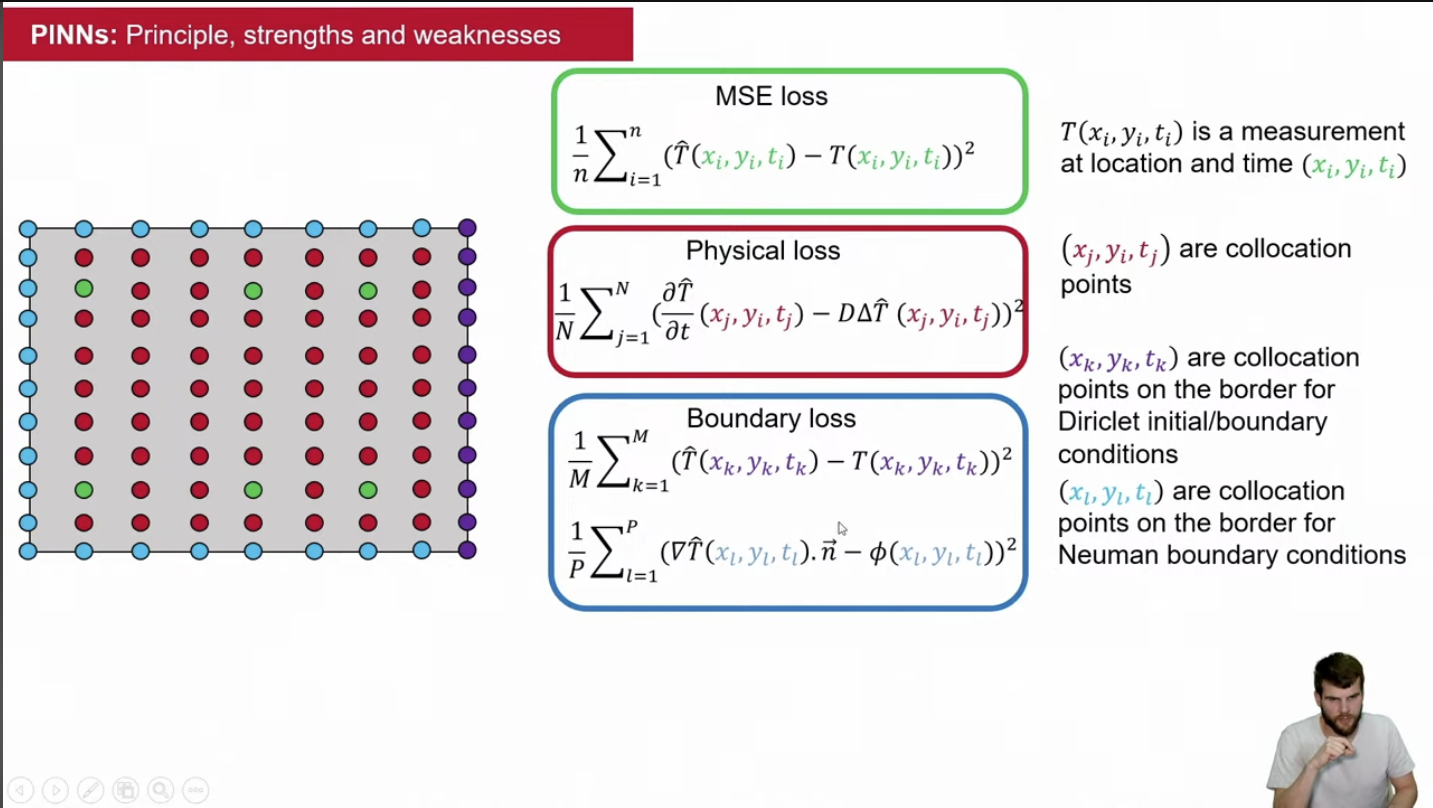

La partie difficile est sur la minimisation de la fonction de loss parce qu'il faut aggréger trois fonctions de loss aux propriétés bien différentes, attention aux echelles de temps
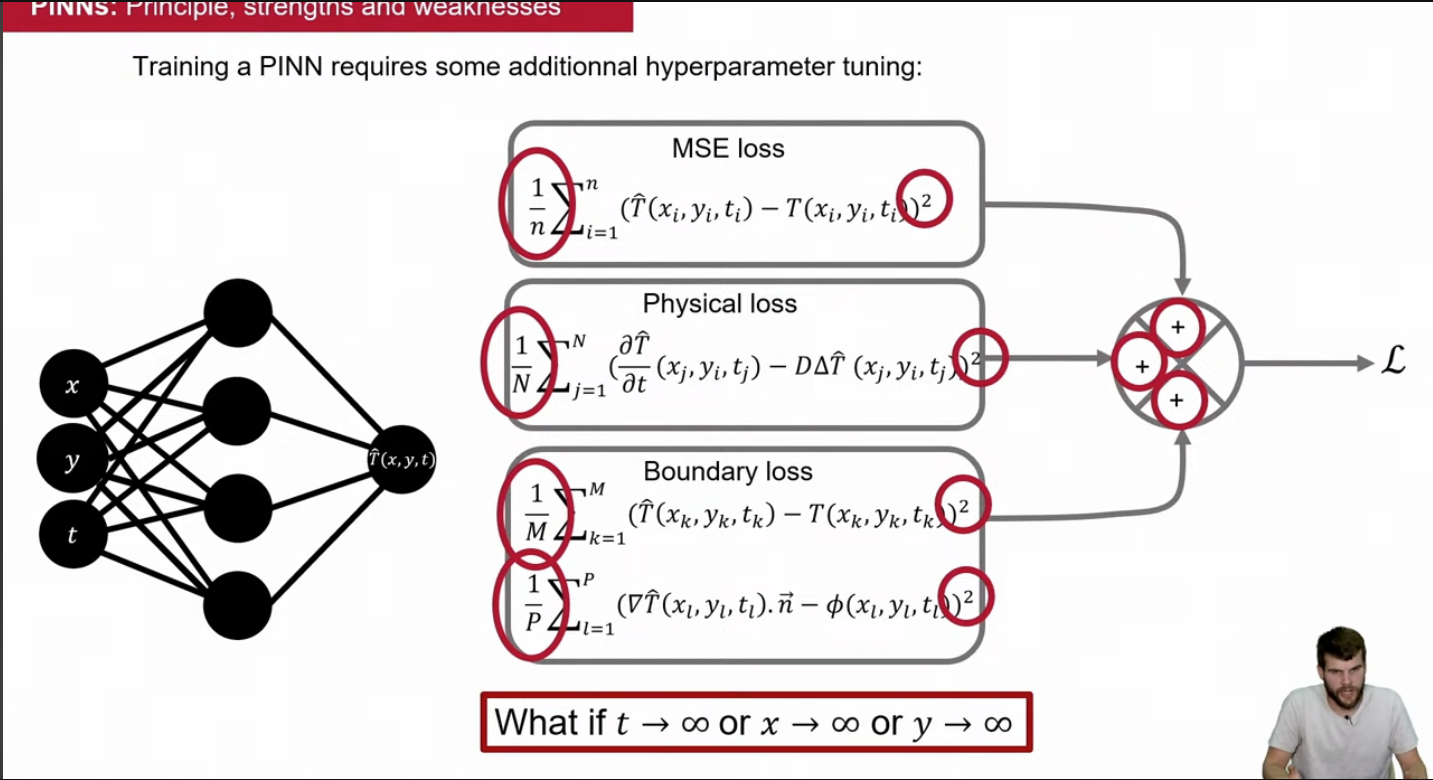

L'espace fonctionnel du rn est très large, et aucune fonction d'estimation qui répondent au probleme physique.
Less loss physisque et conditions aux bornes tendent vers les solutions acceptables.

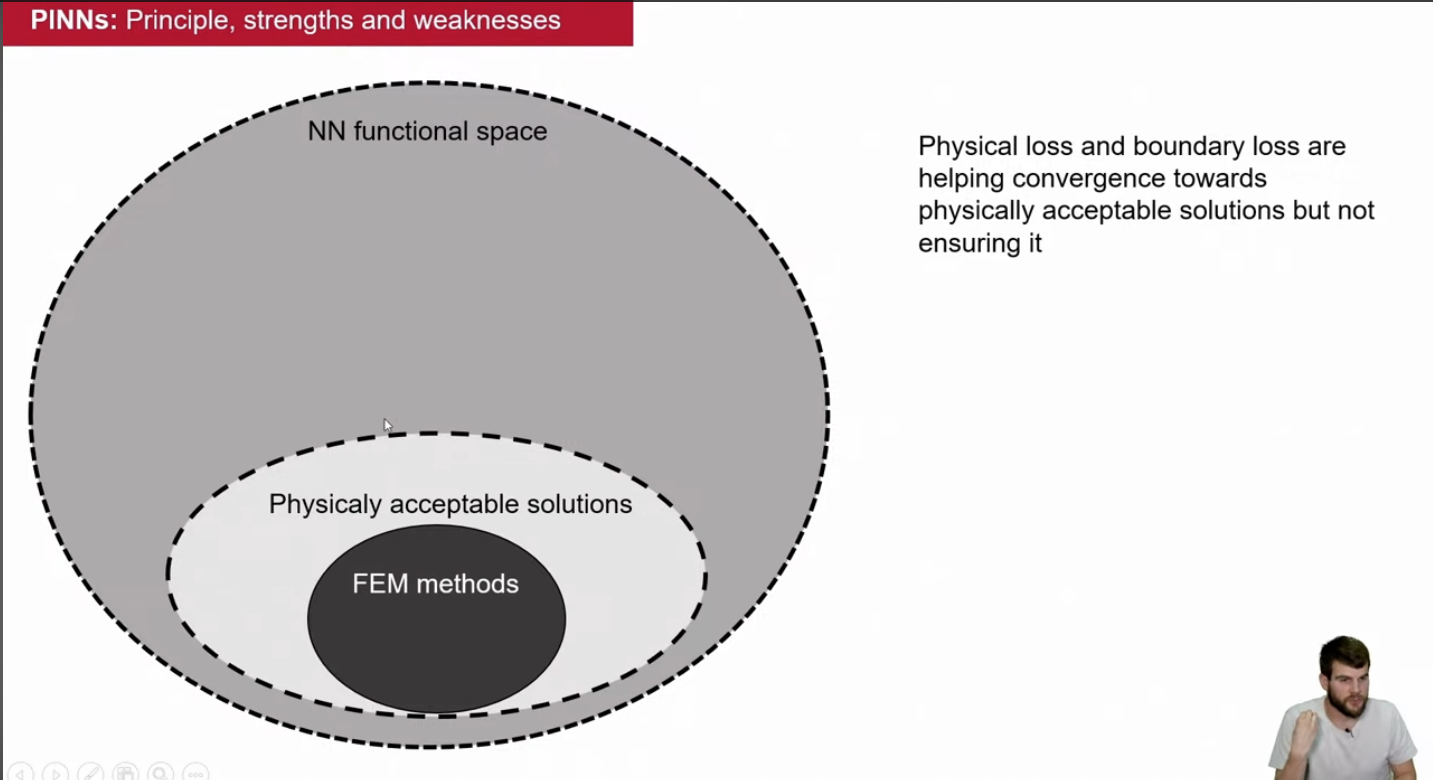

uuuu
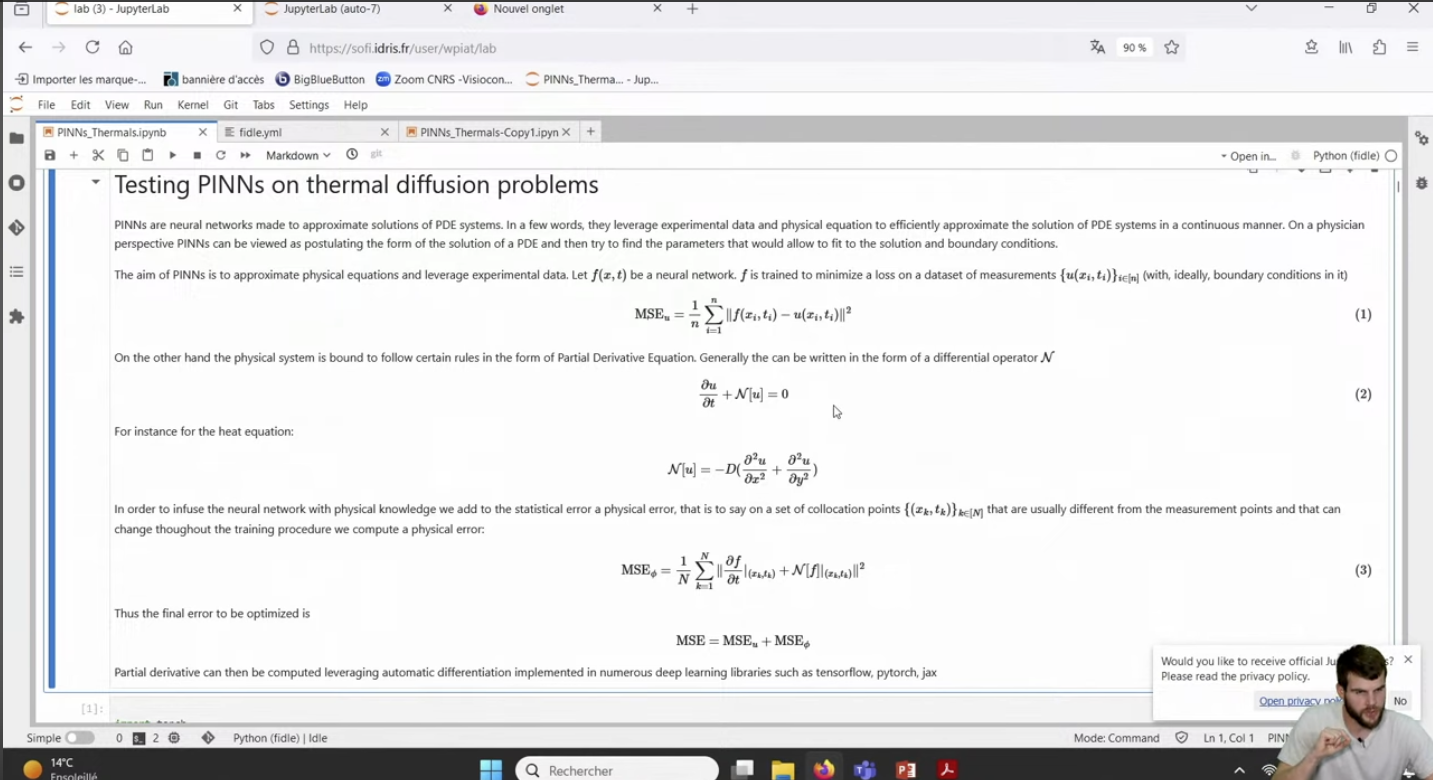

In [2]:
#superclass to initialize the MLP

class MLP(nn.Module):
    def __init__(self, hwidth, hlayers):
        super(MLP, self).__init__()


        #Remember when choosing your transformation funcs : you need non linear transfuncs because of the differenciation and backpropagation
        #Otherwise you end up with a bunch of 0s
        #Splatting with creating a list (python syntax : *layers) : take a list and splat it as args, if a func has 3 inputs : create a list with 3 items, and you'll have a 3 arg func
        layers = [
            nn.Linear(1, hwidth),
            nn.Tanh()
        ]

        for _ in range(hlayers - 1):
            layers.append(nn.Linear(hwidth, hwidth))
            layers.append(nn.Tanh())   
        layers.append(nn.Linear(hwidth, 1))
        self.network = nn.Sequential(*layers) #differenciable à l'ordre de l'equation differencielle traitée

    def forward(self, t): #time t, predict y
        return self.network(t)

In [3]:
def residual(model, t, params):

    m, mu, k = params

    y = model(t)

    dydt = torch.autograd.grad(y, t, grad_outputs=torch.ones_like(y), create_graph=True)[0] #computational graph used for backpropagation
    d2ydt2 = torch.autograd.grad(dydt, t, grad_outputs=torch.ones_like(dydt), create_graph=True)[0]

    return m*d2ydt2 + mu*dydt + k*y #the closer to 0 the better the predictions

In [4]:
#can be data points

def boundary(model, tbc):

    ybc = model(tbc) #evaluate model


    dydt_bc = torch.autograd.grad(ybc, tbc, grad_outputs=torch.ones_like(ybc), create_graph=True)[0] #computational graph used for backpropagation

    return ybc -1, dydt_bc

In [5]:
def datapoints(n_col=64, T=50):
    tbc = torch.zeros(1,1, requires_grad = True)
    tcol = (torch.rand(n_col, 1) * T).requires_grad_(True) #colocation points, verify at certain points where the physical condition is satisfied
    return tbc, tcol

In [11]:
def train(model, tcol, tbc, params, optimizer):
    model.train()

    optimizer.zero_grad()

    #compute boundary conditions
    bc1, bc2 = boundary(model, tbc)
    lossbc1 = torch.mean(bc1**2)
    lossbc2 = torch.mean(bc2**2)


    rcol = residual(model, tcol, params)
    losscol = torch.mean(rcol**2)

    lambda1 = 1e-1; lambda2 = 1e-4
    loss = lossbc1 + lambda1 * lossbc2 + lambda2* losscol

    #backpropagation
    loss.backward() #that's why you needed the create_graph param

    optimizer.step()

    return loss.item(), lossbc1.item(), lossbc2.item(), losscol.item()
    

In [12]:
hlayers = 4
hwidth = 32

model = MLP(hwidth, hlayers)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

#generate evaluation/data points
tbc, tcol = datapoints()
params = (1.0, 0.4, 5.0)

In [13]:
epochs = 400
train_losses = np.zeros(epochs)

for epoch in range (epochs):
    loss, lossbc1, lossbc2, losscol = train(model, tcol, tbc, params, optimizer)

    if epoch % 100 ==0:
        print(f"epoch {epoch} | loss total = {loss:.6f} | bc1 = {lossbc1:.6f} | bc2 = {lossbc2:.6f} | col (résidu physique) = {losscol:.6f}")
        

epoch 0 | loss total = 0.873126 | bc1 = 0.872961 | bc2 = 0.000454 | col (résidu physique) = 1.197831
epoch 100 | loss total = 0.000057 | bc1 = 0.000002 | bc2 = 0.000039 | col (résidu physique) = 0.506817
epoch 200 | loss total = 0.000015 | bc1 = 0.000000 | bc2 = 0.000001 | col (résidu physique) = 0.149913
epoch 300 | loss total = 0.000007 | bc1 = 0.000000 | bc2 = 0.000000 | col (résidu physique) = 0.073012


/var/folders/ph/8txnttk17xdd_j7_th7ry4qw0000gn/T/ipykernel_65339/3417685882.py:2: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


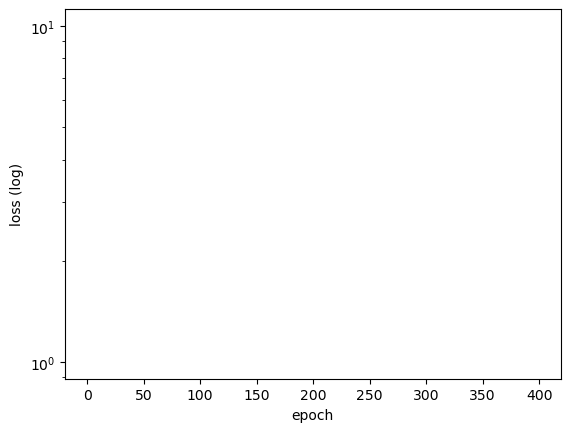

In [14]:
plt.plot(train_losses)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss (log)")
plt.show()

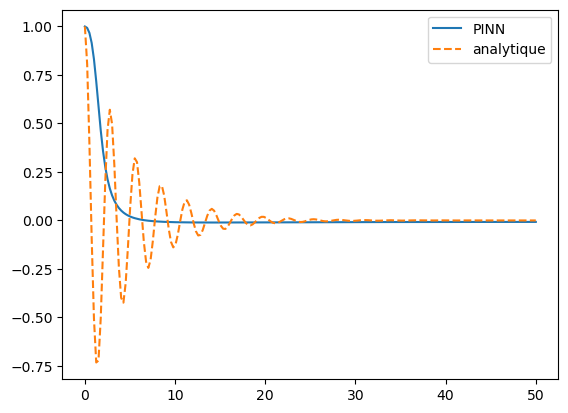

In [15]:
t_test = torch.linspace(0, 50, 200).reshape(-1, 1)
with torch.no_grad():
    y_pred = model(t_test)

m, mu, k = params
omega0 = (k/m) ** 0.5
zeta = mu / (2 * (m*k) ** 0.5)
omega_d = omega0 * (1 - zeta**2) ** 0.5
y_true = torch.exp(-zeta*omega0*t_test) * torch.cos(omega_d*t_test)

plt.plot(t_test, y_pred, label="PINN")
plt.plot(t_test, y_true, "--", label="analytique")
plt.legend(); plt.show()